In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
french = pd.read_csv('postagging_french.csv')
italian = pd.read_csv('postagging_italian.csv')
portuguese = pd.read_csv('postagging_portuguese.csv')

In [5]:
POS_GROUPED = ['VERB', 'NOUN', 'ADJ', 'ADV', 'PRON', 'FUNC', 'PUNCT', 'OTHER']
def stats(df):
	stats = pd.DataFrame(columns=['COUNT', 'PERCENTAGE'])
	overall = len(df)
	for pos in POS_GROUPED:
		count = len(df[df['POS_GROUPED'] == pos])
		stats.loc[pos] = {'COUNT': count, 'PERCENTAGE': (count / overall) * 100}
	return stats

In [6]:
french_stats = stats(french)
italian_stats = stats(italian)
portuguese_stats = stats(portuguese)

In [7]:
print(french_stats)

       COUNT  PERCENTAGE
VERB    1532   14.398496
NOUN    3794   35.657895
ADJ     1382   12.988722
ADV      224    2.105263
PRON     821    7.716165
FUNC    1427   13.411654
PUNCT   1075   10.103383
OTHER    385    3.618421


In [8]:
print(italian_stats)

       COUNT  PERCENTAGE
VERB     874    8.168988
NOUN    3127   29.227031
ADJ      930    8.692401
ADV      295    2.757267
PRON    1087   10.159828
FUNC    2689   25.133190
PUNCT   1410   13.178802
OTHER    287    2.682494


In [9]:
print(portuguese_stats)

       COUNT  PERCENTAGE
VERB    1180   12.525210
NOUN    3967   42.108056
ADJ      782    8.300605
ADV      108    1.146375
PRON     796    8.449209
FUNC    1378   14.626897
PUNCT   1132   12.015710
OTHER     78    0.827938


In [10]:
overall_df = pd.DataFrame(columns=['FRENCH_COUNT', 'FRENCH_PERCENTAGE', 'ITALIAN_COUNT', 'ITALIAN_PERCENTAGE', 'PORTUGUESE_COUNT', 'PORTUGUESE_PERCENTAGE'])
for pos in POS_GROUPED:
	overall_df.loc[pos] = {
		'FRENCH_COUNT': french_stats.loc[pos]['COUNT'],
		'FRENCH_PERCENTAGE': french_stats.loc[pos]['PERCENTAGE'],
		'ITALIAN_COUNT': italian_stats.loc[pos]['COUNT'],
		'ITALIAN_PERCENTAGE': italian_stats.loc[pos]['PERCENTAGE'],
		'PORTUGUESE_COUNT': portuguese_stats.loc[pos]['COUNT'],
		'PORTUGUESE_PERCENTAGE': portuguese_stats.loc[pos]['PERCENTAGE']
	}
print(overall_df)

       FRENCH_COUNT  FRENCH_PERCENTAGE  ITALIAN_COUNT  ITALIAN_PERCENTAGE  \
VERB         1532.0          14.398496          874.0            8.168988   
NOUN         3794.0          35.657895         3127.0           29.227031   
ADJ          1382.0          12.988722          930.0            8.692401   
ADV           224.0           2.105263          295.0            2.757267   
PRON          821.0           7.716165         1087.0           10.159828   
FUNC         1427.0          13.411654         2689.0           25.133190   
PUNCT        1075.0          10.103383         1410.0           13.178802   
OTHER         385.0           3.618421          287.0            2.682494   

       PORTUGUESE_COUNT  PORTUGUESE_PERCENTAGE  
VERB             1180.0              12.525210  
NOUN             3967.0              42.108056  
ADJ               782.0               8.300605  
ADV               108.0               1.146375  
PRON              796.0               8.449209  
FUNC        

<Figure size 1000x600 with 0 Axes>

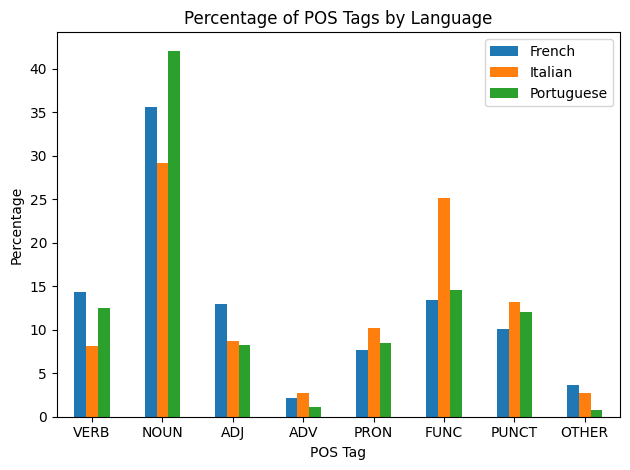

In [12]:
plt.figure(figsize=(10, 6))
plt.grouped_bar = overall_df[['FRENCH_PERCENTAGE', 'ITALIAN_PERCENTAGE', 'PORTUGUESE_PERCENTAGE']].plot(kind='bar')
plt.title('Percentage of POS Tags by Language')
plt.xlabel('POS Tag')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['French', 'Italian', 'Portuguese'])
plt.tight_layout()
plt.show()